In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 3668
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Revenue in the first quarter of the year dropped 15 percent from the same period a year earlier .',
 "With the scandal hanging over Stewart 's company , revenue the first quarter of the year dropped 15 percent from the same period a year earlier .")

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 100]),
 'token_type_ids': torch.Size([32, 100]),
 'attention_mask': torch.Size([32, 100])}

# 4. Load Model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(1.2996, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
teacher_model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
teacher_model.set_use_module_grafting(False)
teacher_model.set_use_scc_status(False)

In [27]:
outputs = teacher_model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.6582, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [28]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
teacher_model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [29]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [30]:
from train_eval_func import eval_loop

In [31]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

In [32]:
teacher_model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [33]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

# 5. FFN Drop

In [34]:
from layer_drop import layer_drop

In [35]:
from layer_merge_helper import reorder_merged_layer_heads, reorder_merged_layer_neurons

In [36]:
from structure_prune_helper import compute_importance_scores, register_importance_masks, remove_importance_masks

In [37]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

  Layer 0: Registered masks (12 heads, 3072 neurons)
  Layer 1: Registered masks (12 heads, 3072 neurons)
  Layer 2: Registered masks (12 heads, 3072 neurons)
  Layer 3: Registered masks (12 heads, 3072 neurons)
  Layer 4: Registered masks (12 heads, 3072 neurons)
  Layer 5: Registered masks (12 heads, 3072 neurons)
  Layer 6: Registered masks (12 heads, 3072 neurons)
  Layer 7: Registered masks (12 heads, 3072 neurons)
  Layer 8: Registered masks (12 heads, 3072 neurons)
  Layer 9: Registered masks (12 heads, 3072 neurons)
  Layer 10: Registered masks (12 heads, 3072 neurons)
  Layer 11: Registered masks (12 heads, 3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [38]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [39]:
cls_reps_similarity = cka_eval.pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
stats = cka_eval.similarity_stats(cls_reps_similarity)

print("  Similarity Stats:")
print(f"    Average: {stats['average']:.6f}")
print(f"    Highest: {stats['max']:.6f}")
print(f"    Lowest:  {stats['min']:.6f}")

CKA Evaluation: 100%|██████████| 115/115 [00:28<00:00,  4.06it/s]

  Similarity Stats:
    Average: 0.899909
    Highest: 0.993659
    Lowest:  0.727776


In [39]:
import matplotlib.pyplot as plt
import seaborn as sn

Text(50.722222222222214, 0.5, 'Layer')

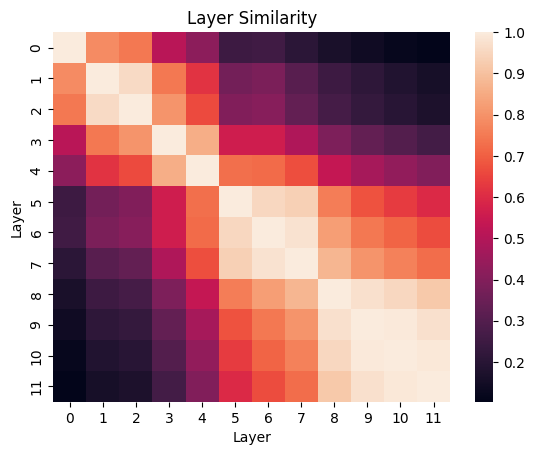

In [41]:
title = "Layer Similarity"
plt.title(title)
sn.heatmap(data = cls_reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [42]:
adj_similarities = []
for i in range(1, len(cls_reps_similarity)):
    adj_similarities.append(cls_reps_similarity[i-1][i])

print(adj_similarities)

[0.7863255, 0.9589766, 0.8026428, 0.8584527, 0.7277758, 0.953493, 0.9786348, 0.87439555, 0.97463083, 0.99365866, 0.9900159]


In [43]:
adj_similarities = torch.tensor(adj_similarities)
adj_similarities

tensor([0.7863, 0.9590, 0.8026, 0.8585, 0.7278, 0.9535, 0.9786, 0.8744, 0.9746,
        0.9937, 0.9900])

In [44]:
# Sort descending
values, indices = torch.sort(adj_similarities, descending=True)

print(indices)
print(values)

tensor([ 9, 10,  6,  8,  1,  5,  7,  3,  2,  0,  4])
tensor([0.9937, 0.9900, 0.9786, 0.9746, 0.9590, 0.9535, 0.8744, 0.8585, 0.8026,
        0.7863, 0.7278])


In [45]:
head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

Computing importance (heads + FFN): 100%|██████████| 115/115 [00:22<00:00,  5.21it/s]


In [46]:
layer_scores = torch.tensor([
    h.mean().item()
    for h in head_importance
])

print(layer_scores.shape)
print(layer_scores)

torch.Size([12])
tensor([4.5827e-06, 4.9624e-06, 4.9156e-06, 5.0245e-06, 3.5533e-06, 4.6235e-06,
        1.9156e-06, 1.3816e-06, 1.7475e-06, 1.6158e-06, 5.8049e-07, 4.9293e-07])


In [47]:
normalized_scores = (
    (layer_scores - layer_scores.min())
    / (layer_scores.max() - layer_scores.min())
)
normalized_scores

tensor([0.9025, 0.9863, 0.9760, 1.0000, 0.6753, 0.9115, 0.3139, 0.1961, 0.2769,
        0.2478, 0.0193, 0.0000])

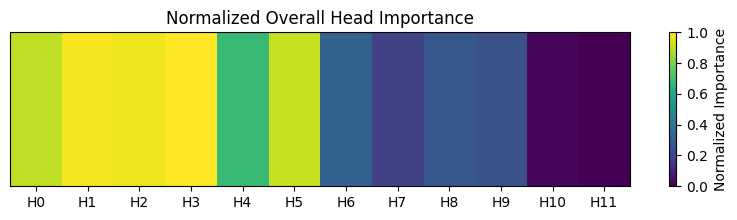

In [48]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall Head Importance")

plt.show()

In [49]:
neuron_layer_scores = torch.tensor([
    h.mean().item()
    for h in neuron_importance
])

print(neuron_layer_scores.shape)
print(neuron_layer_scores)

torch.Size([12])
tensor([1.2776e-07, 1.2702e-07, 1.4722e-07, 1.4433e-07, 1.4026e-07, 9.6833e-08,
        9.0939e-08, 8.1933e-08, 5.6636e-08, 2.9283e-08, 1.8077e-08, 1.1032e-08])


In [50]:
neuron_normalized_scores = (
    (neuron_layer_scores - neuron_layer_scores.min())
    / (neuron_layer_scores.max() - neuron_layer_scores.min())
)
neuron_normalized_scores

tensor([0.8571, 0.8516, 1.0000, 0.9788, 0.9489, 0.6300, 0.5867, 0.5206, 0.3349,
        0.1340, 0.0517, 0.0000])

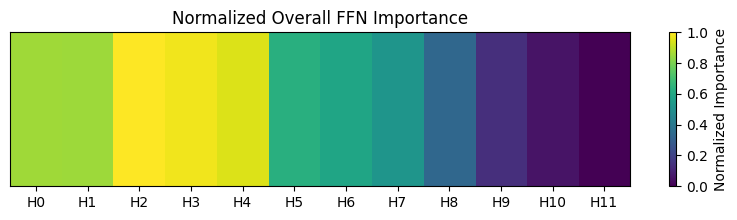

In [51]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    neuron_normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall FFN Importance")

plt.show()

In [40]:
def layer_score(importance):
    layer_scores = torch.tensor([
        h.mean().item()
        for h in importance
    ])

    normalized_scores = (
        (layer_scores - layer_scores.min())
        / (layer_scores.max() - layer_scores.min())
    )
    
    return normalized_scores

In [53]:
layer_score(neuron_importance)

tensor([0.8571, 0.8516, 1.0000, 0.9788, 0.9489, 0.6300, 0.5867, 0.5206, 0.3349,
        0.1340, 0.0517, 0.0000])

In [41]:
def prune_mlp(model, layer):
    """ This method shows how to prune head (remove heads weights) based on
        the head importance scores as described in Michel et al. (http://arxiv.org/abs/1905.10650)
    """
    original_num_params = sum(p.numel() for p in model.parameters())
    model.prune_mlps([layer])
    pruned_num_params = sum(p.numel() for p in model.parameters())

    model.bert.encoder.layer[layer].int_mask_param = None
    
    print("Pruning, original num of params:  %.2e, after pruning %.2e (%.1f percents)" % (original_num_params, pruned_num_params, pruned_num_params / original_num_params * 100))

In [42]:
from train_eval_func import get_primary_metric, set_lr_scheduler, train
from layer_merge_helper import merge_mha
from torch.optim import AdamW
import os

In [43]:
def test_func(
    model,
    train_dataloader,
    val_dataloader,
    task_name,
    device,
    init_metric,
    cka_evaluator=None,
    num_merges=6,
    target_layers=[3, 4, 5, 6, 7],
    recovery_epochs=10,
    recovery_lr=1e-5,
    patience=2,
    save_dir='./weights/',
    keep_temp_checkpoints=False,
    cka_max_iter=float("Inf"),
    imp_score_max_batches=float("Inf"),
    teacher_model=None,
    alpha=0.5,
    temperature=6,
    drop_strategy="top",
    regression=False
):
    recovery_dir = save_dir
    
    target_metric = get_primary_metric(task_name)
    threshold = init_metric[target_metric] * 0.01
    
    print(f"Target Metric for {task_name}: {target_metric}")
    print(f"Original {target_metric} score: {init_metric[target_metric]:.4f}")
    print(f"Recovery threshold: {threshold:.4f}")
    print("")

    layer_composition = []
    for layer in range(12):
        layer_composition.append(
            {"layer": 12, "mlp_present": True}
        )
        
    for iteration in range(12):
        print(" --> Iteration:", iteration)
        # similarity score
        cls_reps_similarity = cka_evaluator.pairwise(
            model, 
            train_dataloader, 
            device, 
            only_cls_token=True, 
            max_iter=cka_max_iter
        )
        stats = cka_evaluator.similarity_stats(cls_reps_similarity)
        
        print("  Similarity Stats:")
        print(f"    Average: {stats['average']:.6f}")
        print(f"    Highest: {stats['max']:.6f}")
        print(f"    Lowest:  {stats['min']:.6f}")
    
        # get adjacent layer pairs
        adj_similarities = []
        for i in range(1, len(cls_reps_similarity)):
            adj_similarities.append(cls_reps_similarity[i-1][i])
    
        adj_similarities = torch.tensor(adj_similarities)
        
        # Sort descending
        values, indices = torch.sort(adj_similarities, descending=True)
        most_similar_pair = int(indices[0])
        print(f"Most similar layers pair: {most_similar_pair}, {most_similar_pair+1}")
    
        # senstivity score
        head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True, max_batches=imp_score_max_batches)
        
        head_imp1, indices1 = torch.sort(head_importance[most_similar_pair], descending=True)
        head_imp2, indices2 = torch.sort(head_importance[most_similar_pair+1], descending=True)
        
        if (model.bert.encoder.layer[most_similar_pair].int_mask_param is not None) and (model.bert.encoder.layer[most_similar_pair+1].int_mask_param is not None): 
            eps = 1e-8
            
            ffn_pair_ratio = float(neuron_importance[most_similar_pair + 1].sum() / neuron_importance[most_similar_pair].sum() + eps)
            if ffn_pair_ratio < 0.2:
                layer_composition[most_similar_pair + 1]["mlp_present"] = False
                prune_mlp(model, most_similar_pair + 1)
            else:
                layer_composition[most_similar_pair]["mlp_present"] = False
                prune_mlp(model, most_similar_pair)
            print("MLP removal used!")
                
        elif model.bert.encoder.layer[most_similar_pair+1].int_mask_param is None:
            merge_mha(model, model.bert.encoder.layer[most_similar_pair+1], model.bert.encoder.layer[most_similar_pair], head_imp1, head_imp2, device, 4)
            layers = list(model.bert.encoder.layer)
            layers.pop(most_similar_pair + 1)
            layer_composition.pop(most_similar_pair + 1)
            
            model.bert.encoder.layer = torch.nn.ModuleList(layers)
            model.config.num_hidden_layers -= 1
            print(f"Merged. Removed layer: {most_similar_pair+1}")
        elif model.bert.encoder.layer[most_similar_pair].int_mask_param is None:
            merge_mha(model, model.bert.encoder.layer[most_similar_pair], model.bert.encoder.layer[most_similar_pair+1], head_imp1, head_imp2, device, 4)
            layers = list(model.bert.encoder.layer)
            layers.pop(most_similar_pair)
            layer_composition.pop(most_similar_pair)
            
            model.bert.encoder.layer = torch.nn.ModuleList(layers)
            model.config.num_hidden_layers -= 1
            print(f"Merged. Removed layer: {most_similar_pair}")
    
        # Post Drop Performance 
        eval_metric = eval_loop(model, val_dataloader, task_name, device, regression=regression)[0]
        
        print("  Post Operation Metrics:")
        for metric_name, value in eval_metric.items():
            marker = "★" if metric_name == target_metric else " "
            print(f"    {marker} {metric_name}: {value:.4f}")

    
        # Recovery Training
        diff = init_metric[target_metric] - eval_metric[target_metric]
        print(f"  Performance drop: {diff:.4f} (threshold: {threshold:.4f})")

        is_retrained = False
        if diff > threshold:
            print("  → Recovery training NEEDED")

            # Setup optimizer and scheduler
            optimizer = AdamW(model.parameters(), lr=recovery_lr)
            num_training_steps = recovery_epochs * len(train_dataloader)
            lr_scheduler = set_lr_scheduler(
                optimizer=optimizer,
                num_training_steps=num_training_steps
            )
            
            print(f"  → Training: {recovery_epochs} epochs, lr={recovery_lr}")
            
            # Temporary checkpoint path
            temp_save_path = os.path.join(recovery_dir, f'temp_iter{iteration}-{task_name}.pt')
            
            # Train with checkpoint saving
            # lr_scheduler= None
            train_stats = train(
                model,
                train_dataloader,
                val_dataloader,
                task_name,
                device,
                num_epochs=recovery_epochs,
                lr=recovery_lr,
                patience=patience,
                use_early_stopping=True,
                optimizer=optimizer,
                lr_scheduler=lr_scheduler,
                save_path=temp_save_path,
                display_epoch_iter=True,
                regression=regression,
                teacher_model=teacher_model, alpha=alpha, temperature=temperature
            )

             # CRITICAL: Reload best checkpoint
            print("\n  → Loading best checkpoint...")
            best_checkpoint = torch.load(temp_save_path)
            model.load_state_dict(best_checkpoint['model_state_dict'])
            
            print(f"  ✓ Loaded best checkpoint from epoch {best_checkpoint['epoch']}")
            print(f"    Best val loss: {best_checkpoint['val_loss']:.4f}")
            print(f"    Best val metrics: {best_checkpoint['val_metrics']}")
            
            # merge_history['metrics_after_recovery'].append(best_checkpoint['val_metrics'])
            # merge_history['training_stats'].append(train_stats)
            
            # Clean up temp checkpoint if not keeping
            if not keep_temp_checkpoints:
                os.remove(temp_save_path)
                print(f"  ✓ Cleaned up temporary checkpoint")

            is_retrained = True
        else:
            print("  → Recovery training NOT needed")

        print("")

    return layer_composition

In [44]:
init_metric = eval_loop(model, val_dataloader, task_name, device)[0]
init_metric

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

In [45]:
performance_track = test_func(
    model, train_dataloader, val_dataloader, task_name, device, init_metric=init_metric, num_merges=9,
    cka_evaluator=cka_eval, teacher_model=teacher_model, drop_strategy="imp_score_merge", recovery_lr=1e-5
)

Target Metric for mrpc: f1
Original f1 score: 0.9094
Recovery threshold: 0.0091

 --> Iteration: 0


CKA Evaluation: 100%|██████████| 115/115 [00:07<00:00, 15.22it/s]


  Similarity Stats:
    Average: 0.899861
    Highest: 0.993713
    Lowest:  0.724249
Most similar layers pair: 9, 10


Computing importance (heads + FFN): 100%|██████████| 115/115 [00:11<00:00, 10.28it/s]


Pruning, original num of params:  1.10e+08, after pruning 1.05e+08 (95.7 percents)
MLP removal used!
  Post Operation Metrics:
      accuracy: 0.8799
    ★ f1: 0.9160
  Performance drop: -0.0066 (threshold: 0.0091)
  → Recovery training NOT needed

 --> Iteration: 1


...

Training:  90%|████████▉ | 1034/1150 [02:46<00:11, 10.06it/s]


<----------------- Epoch 9 ----------------->
Loss: 0.07, Training Metrics:
  accuracy: 0.9907
  f1: 0.9931
Validation Loss: 1.34, Validation Metrics:
  accuracy: 0.8211
  f1: 0.8817
Elapsed Time: 12.8158 sec


Training: 100%|██████████| 1150/1150 [03:00<00:00,  6.36it/s]


<----------------- Epoch 10 ----------------->
Loss: 0.07, Training Metrics:
  accuracy: 0.9896
  f1: 0.9923
Validation Loss: 1.31, Validation Metrics:
  accuracy: 0.8260
  f1: 0.8842
Elapsed Time: 13.0156 sec
>>>>> Early stopping callback <<<<<

Total Training Time: 180.83 sec
Chosen Primary Metric: f1
Best Metric Run: 0.8849

  → Loading best checkpoint...


  ✓ Loaded best checkpoint from epoch 8
    Best val loss: 1.2591
    Best val metrics: {'accuracy': 0.8284313725490197, 'f1': 0.8848684210526315}
  ✓ Cleaned up temporary checkpoint



In [46]:
performance_track

[{'layer': 12, 'mlp_present': True},
 {'layer': 12, 'mlp_present': True},
 {'layer': 12, 'mlp_present': True},
 {'layer': 12, 'mlp_present': True},
 {'layer': 12, 'mlp_present': True},
 {'layer': 12, 'mlp_present': True}]

In [46]:
cls_reps_similarity = cka_eval.pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
stats = cka_eval.similarity_stats(cls_reps_similarity)

print("  Similarity Stats:")
print(f"    Average: {stats['average']:.6f}")
print(f"    Highest: {stats['max']:.6f}")
print(f"    Lowest:  {stats['min']:.6f}")

CKA Evaluation: 100%|██████████| 115/115 [00:03<00:00, 32.56it/s]

  Similarity Stats:
    Average: 0.818365
    Highest: 0.917727
    Lowest:  0.752553


Text(50.722222222222214, 0.5, 'Layer')

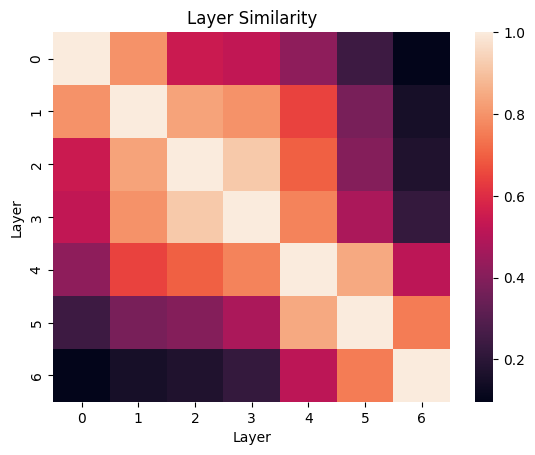

In [47]:
title = "Layer Similarity"
plt.title(title)
sn.heatmap(data = cls_reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [56]:
temp = layer_score(neuron_importance)
temp

tensor([0.8571, 0.8516, 1.0000, 0.9788, 0.9489, 0.6300, 0.5867, 0.5206, 0.3349,
        0.1340, 0.0517, 0.0000])

In [57]:
model.bert.encoder.layer[10]

BertLayer(
  (attention): BertAttention(
    (self): BertSelfAttention(
      (query): Linear(in_features=768, out_features=768, bias=True)
      (key): Linear(in_features=768, out_features=768, bias=True)
      (value): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (output): BertSelfOutput(
      (dense): Linear(in_features=768, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (intermediate): BertIntermediate(
    (dense): Linear(in_features=768, out_features=3072, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): BertOutput(
    (dense): Linear(in_features=3072, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)

In [59]:
prune_mlp(model, 10)

Pruning, original num of params:  1.10e+08, after pruning 1.05e+08 (95.7 percents)


In [60]:
model.bert.encoder.layer[10]

BertLayer(
  (attention): BertAttention(
    (self): BertSelfAttention(
      (query): Linear(in_features=768, out_features=768, bias=True)
      (key): Linear(in_features=768, out_features=768, bias=True)
      (value): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (output): BertSelfOutput(
      (dense): Linear(in_features=768, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (intermediate): None
  (output): BertOutput(
    (dense): None
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)

In [61]:
model.bert.encoder.layer[10].int_mask_param = None

In [62]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8137254901960784, 'f1': 0.8782051282051282}

In [63]:
model.bert.encoder.layer[11]

BertLayer(
  (attention): BertAttention(
    (self): BertSelfAttention(
      (query): Linear(in_features=768, out_features=768, bias=True)
      (key): Linear(in_features=768, out_features=768, bias=True)
      (value): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (output): BertSelfOutput(
      (dense): Linear(in_features=768, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (intermediate): BertIntermediate(
    (dense): Linear(in_features=768, out_features=3072, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): BertOutput(
    (dense): Linear(in_features=3072, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)

In [64]:
eval_loop(teacher_model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

In [65]:
prune_mlp(teacher_model, 11)

Pruning, original num of params:  1.09e+08, after pruning 1.05e+08 (95.7 percents)


In [66]:
eval_loop(teacher_model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8774509803921569, 'f1': 0.9152542372881356}

In [48]:
head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

Computing importance (heads + FFN): 100%|██████████| 115/115 [00:06<00:00, 18.49it/s]


In [49]:
layer_scores = torch.tensor([
    h.mean().item()
    for h in head_importance
])

print(layer_scores.shape)
print(layer_scores)

torch.Size([7])
tensor([6.9565e-06, 5.8844e-06, 7.5890e-06, 6.1062e-06, 8.4297e-06, 2.1618e-06,
        2.6492e-06])


In [50]:
normalized_scores = (
    (layer_scores - layer_scores.min())
    / (layer_scores.max() - layer_scores.min())
)
normalized_scores

tensor([0.7650, 0.5939, 0.8659, 0.6293, 1.0000, 0.0000, 0.0778])

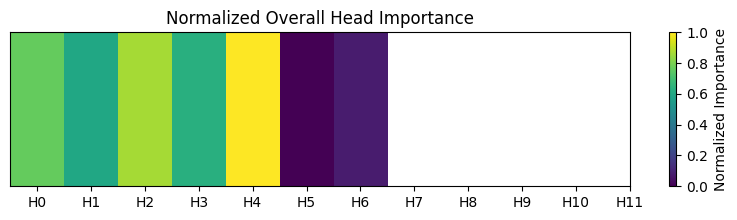

In [51]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall Head Importance")

plt.show()

In [53]:
neuron_importance

[tensor([1.2795e-07, 1.0675e-07, 9.9785e-08,  ..., 9.8951e-08, 1.2216e-07,
         9.2955e-08], device='cuda:1'),
 tensor([1.1145e-07, 1.8922e-07, 1.2737e-07,  ..., 1.4001e-07, 1.6930e-07,
         1.9407e-07], device='cuda:1'),
 None,
 tensor([2.7743e-07, 1.5245e-07, 3.4899e-07,  ..., 2.1609e-07, 1.7415e-07,
         9.0388e-08], device='cuda:1'),
 None,
 tensor([2.5509e-08, 6.2057e-08, 5.6975e-08,  ..., 1.7156e-07, 3.1758e-08,
         4.8740e-07], device='cuda:1'),
 tensor([4.1890e-09, 7.4680e-08, 5.1935e-08,  ..., 3.9124e-09, 3.4212e-08,
         1.7133e-08], device='cuda:1')]

In [54]:
neuron_layer_scores = torch.tensor([
    h.mean().item() if h is not None else 0.0
    for h in neuron_importance
])

print(neuron_layer_scores.shape)
print(neuron_layer_scores)

torch.Size([7])
tensor([1.9215e-07, 2.7804e-07, 0.0000e+00, 2.1115e-07, 0.0000e+00, 8.7824e-08,
        2.1577e-08])


In [55]:
neuron_normalized_scores = (
    (neuron_layer_scores - neuron_layer_scores.min())
    / (neuron_layer_scores.max() - neuron_layer_scores.min())
)
neuron_normalized_scores

tensor([0.6911, 1.0000, 0.0000, 0.7594, 0.0000, 0.3159, 0.0776])

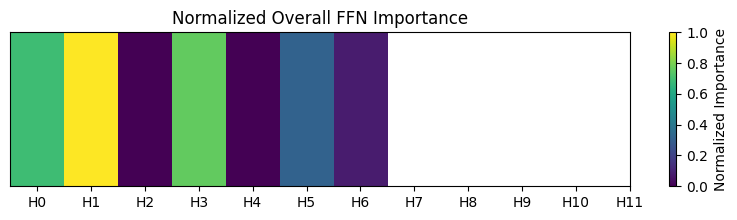

In [56]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    neuron_normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall FFN Importance")

plt.show()